In [ ]:
import pandas as pd

In [ ]:
#TASK 1

df = pd.read_csv("data_banknote_authentication.txt", header=None, names=["variance", "skewness", "curtosis", "entropy", "class"])

#1. First 5 samples
print(df.head())
print("\n")

#2. Dataset dimension
print(df.shape)
print("\n")

#3. Missing values
print(df.isnull().sum())
print("\n")

#4. Descriptive statistics
print(df.describe())
print("\n")

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


(1372, 5)


variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

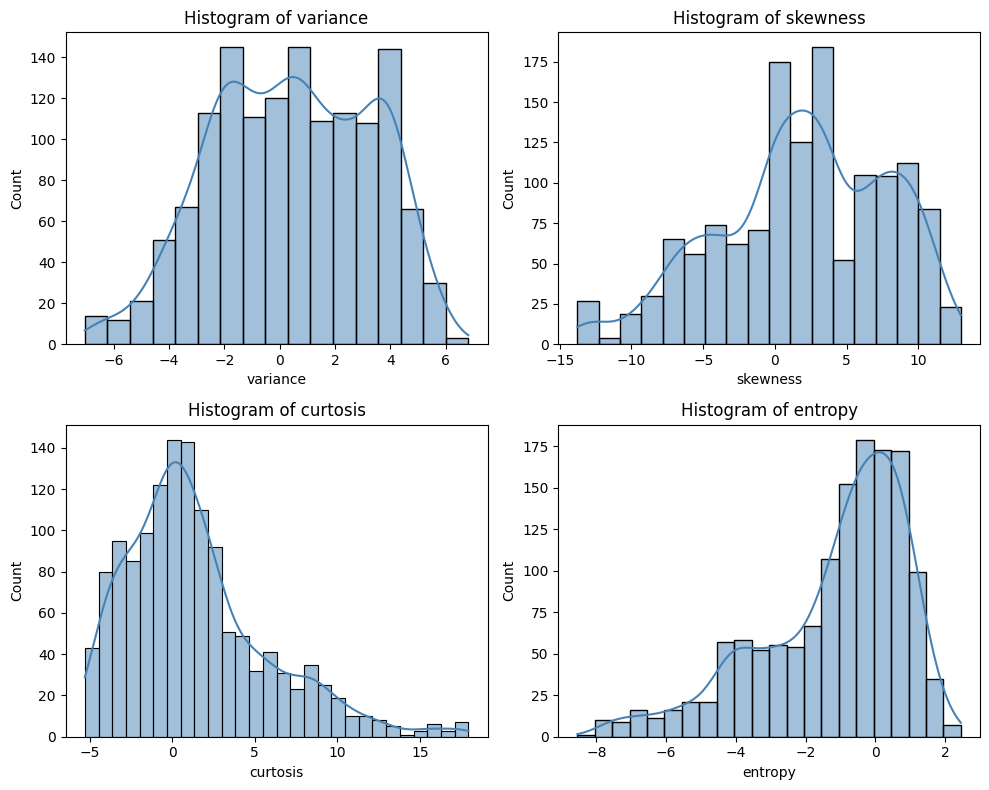

In [ ]:
#TASK 2

#Histogram

feature_cols = ["variance", "skewness", "curtosis", "entropy"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

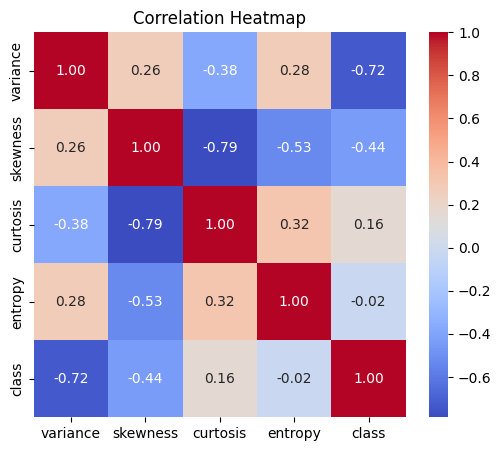

In [ ]:
#Heatmap

plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

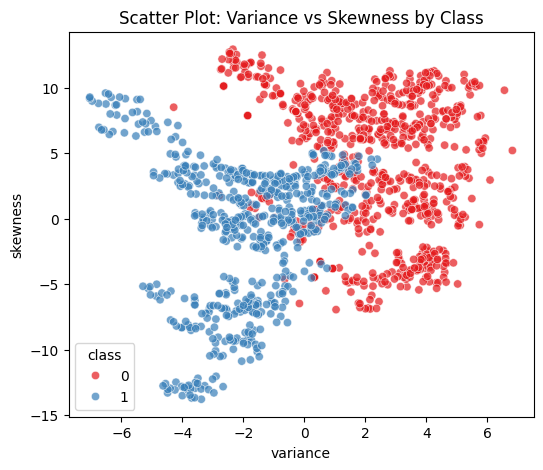

In [ ]:
#Scatter Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="variance", y="skewness", hue="class", palette="Set1", alpha=0.7)
plt.title("Scatter Plot: Variance vs Skewness by Class")
plt.show()

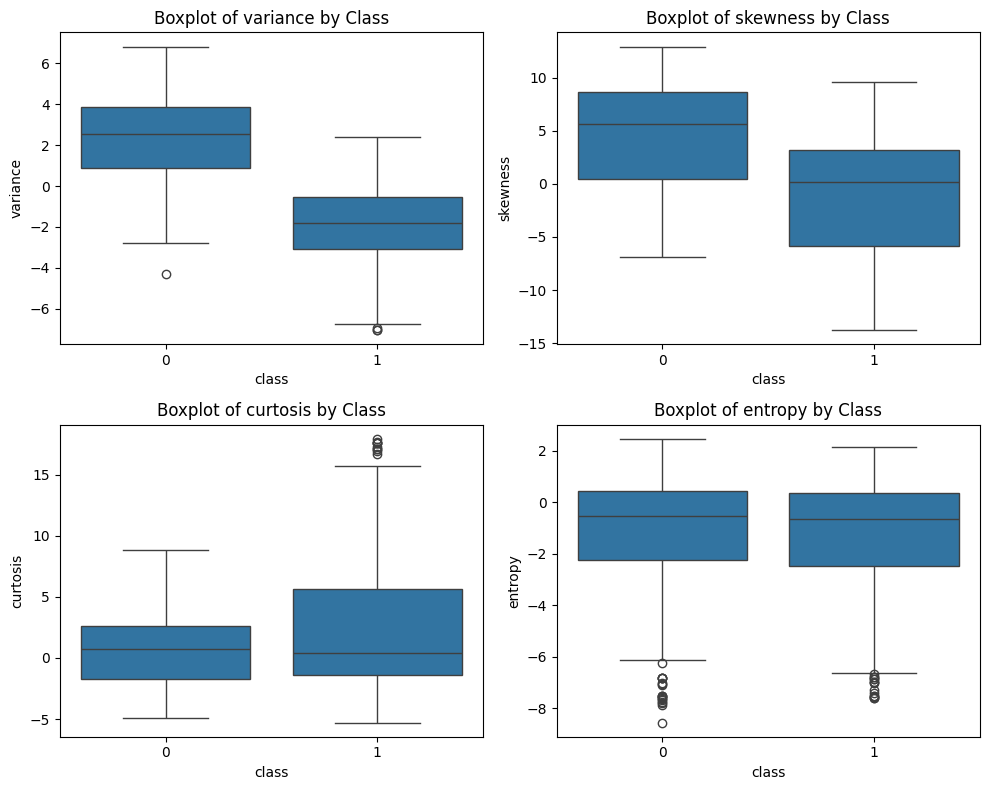

In [ ]:
#Box plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.boxplot(data=df, x="class", y=col, ax=ax)
    ax.set_title(f"Boxplot of {col} by Class")
plt.tight_layout()
plt.show()

In [ ]:
#TASK 3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ["variance", "skewness", "curtosis", "entropy"]

X = df[feature_cols].values
y = df["class"].values

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 1097
Testing set size: 275


In [ ]:
#TASK 4 & 5
import numpy as np

n_features = X_train.shape[1]
rng = np.random.default_rng(42)
w = rng.normal(0, 0.01, size=n_features)
b = 0.0

class SingleLayerPerceptron:
    def __init__(self, n_features, learning_rate=0.01, epochs=50, random_state=42):
        rng = np.random.default_rng(random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.lr = learning_rate
        self.epochs = epochs

    @staticmethod
    def step_activation(z):
        return np.where(z >= 0, 1, 0)

    def forward(self, x_row):
        z = np.dot(self.w, x_row) + self.b
        return self.step_activation(z)

    def predict(self, X):
      z = X @ self.w + self.b   # matrix-vector product: does the dot product for every row at once
      return self.step_activation(z)

    def fit(self, X, y, verbose=True):
      n_samples = X.shape[0]
      self.history = []  # to log epoch-wise errors/weights/bias

      for epoch in range(1, self.epochs + 1):
          misclassified = 0
          for i in range(n_samples):
              x_i = X[i]
              y_i = y[i]
              y_hat = self.forward(x_i)
              error = y_i - y_hat

              if error != 0:
                  misclassified += 1
                  self.w += self.lr * error * x_i
                  self.b += self.lr * error

          self.history.append({
              "epoch": epoch,
              "errors": misclassified,
              "w": self.w.copy(),
              "b": self.b
          })

          if verbose:
              print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                    f"w: {self.w} | b: {self.b:.4f}")

          if misclassified == 0:
              print(f"Converged at epoch {epoch}")
              break

In [ ]:
model = SingleLayerPerceptron(n_features=X_train.shape[1])
prediction = model.forward(X_train[0])
print("Predicted:", prediction, "| Actual:", y_train[0])

Predicted: 0 | Actual: 1


In [ ]:
model = SingleLayerPerceptron(n_features=X_train.shape[1], learning_rate=0.01, epochs=50)
model.fit(X_train, y_train)

Epoch   1 | Misclassified:   51 | w: [-0.06263851 -0.0793464  -0.06353158 -0.0027874 ] | b: -0.0300
Epoch   2 | Misclassified:   24 | w: [-0.07620143 -0.10232141 -0.06460141 -0.00030581] | b: -0.0300
Epoch   3 | Misclassified:   23 | w: [-0.07800137 -0.09653703 -0.09136325 -0.00220732] | b: -0.0400
Epoch   4 | Misclassified:   32 | w: [-0.08855197 -0.11267296 -0.09797166 -0.00557945] | b: -0.0600
Epoch   5 | Misclassified:   26 | w: [-0.096734   -0.1214235  -0.10624506 -0.00609032] | b: -0.0600
Epoch   6 | Misclassified:   20 | w: [-0.1096048  -0.13468495 -0.10400392 -0.00233011] | b: -0.0400
Epoch   7 | Misclassified:   23 | w: [-0.1161203  -0.14283593 -0.1101345  -0.00416361] | b: -0.0500
Epoch   8 | Misclassified:   20 | w: [-0.10586681 -0.14317078 -0.12465455 -0.00020881] | b: -0.0700
Epoch   9 | Misclassified:   23 | w: [-0.12493671 -0.15326481 -0.11722008  0.00349083] | b: -0.0600
Epoch  10 | Misclassified:   18 | w: [-0.11985815 -0.16083737 -0.12356053  0.00915496] | b: -0.0600


In [ ]:
#TASK 6
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0
 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0
 1 0 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1
 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 1 0 1 0 1 0 1
 0 0 1 0 1 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0
 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 0 0
 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0
 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy : 0.9891
Precision: 0.9837
Recall   : 0.9918
F1-score : 0.9878
Confusion Matrix:
 [[151   2]
 [  1 121]]


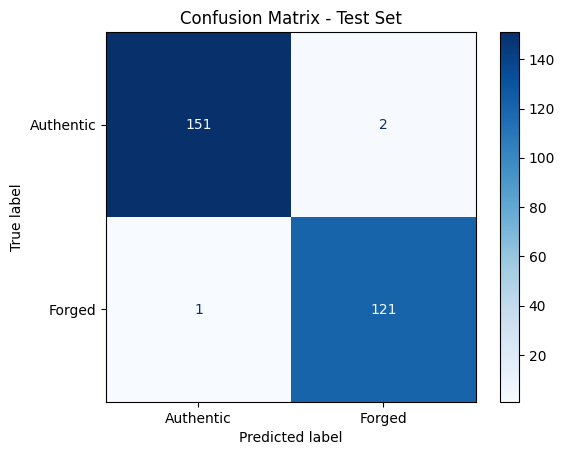

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic", "Forged"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()